In [1]:
from pathlib import Path
data_dir = Path("/Users/elioteaton/Documents/git_repos/toposhapes_package/data")
dem_path = data_dir / "P.dem"
par_path = data_dir / "P.dem_par"   # change this if your parameter file has another name

assert dem_path.exists(), f"DEM not found: {dem_path}"
assert par_path.exists(), f"Parameter file not found: {par_path}"

print("DEM:", dem_path.resolve())
print("DEM size:", dem_path.stat().st_size, "bytes")

print("\n--- Parameter file ---")
par_text = par_path.read_text(errors="replace")
print(par_text)

DEM: /Users/elioteaton/Documents/git_repos/toposhapes_package/data/P.dem
DEM size: 57196932 bytes

--- Parameter file ---
Gamma DIFF&GEO DEM/MAP parameter file
title: sinabung_cop30
DEM_projection:     EQA
data_format:        REAL*4
DEM_hgt_offset:          0.00000
DEM_scale:               1.00000
width:                4089
nlines:               3497
corner_lat:      3.2336112  decimal degrees
corner_lon:     98.3266666  decimal degrees
post_lat:   -3.4722223e-05  decimal degrees
post_lon:    3.4722223e-05  decimal degrees

ellipsoid_name: WGS 84
ellipsoid_ra:        6378137.000   m
ellipsoid_reciprocal_flattening:  298.2572236

datum_name: WGS 84
datum_shift_dx:              0.000   m
datum_shift_dy:              0.000   m
datum_shift_dz:              0.000   m
datum_scale_m:         0.00000e+00
datum_rotation_alpha:  0.00000e+00   arc-sec
datum_rotation_beta:   0.00000e+00   arc-sec
datum_rotation_gamma:  0.00000e+00   arc-sec
datum_country_list: WGS 84




In [2]:
import numpy as np

width = 4089
nlines = 3497

# Read just the first 20 samples in both possible byte orders.
sample_be = np.fromfile(dem_path, dtype=">f4", count=20)
sample_le = np.fromfile(dem_path, dtype="<f4", count=20)

print("Big-endian interpretation:")
print(sample_be)

print("\nLittle-endian interpretation:")
print(sample_le)

print("\nBig-endian finite:", np.isfinite(sample_be).all())
print("Little-endian finite:", np.isfinite(sample_le).all())

print("\nBig-endian range:",
      np.nanmin(sample_be), np.nanmax(sample_be))

print("Little-endian range:",
      np.nanmin(sample_le), np.nanmax(sample_le))

Big-endian interpretation:
[1470.9156 1470.9548 1471.0723 1471.2681 1471.5422 1471.8246 1472.0452
 1472.204  1472.301  1472.3363 1472.3097 1472.2214 1472.0713 1471.8627
 1471.5985 1471.279  1470.9042 1470.4739 1469.9882 1469.447 ]

Little-endian interpretation:
[ 4.6497190e+08 -5.4903704e-30  3.0429290e+10 -2.3498299e-26
  3.4018486e+16  9.2497834e+21  2.5693651e+30 -1.0135190e-34
 -1.8664512e-18 -1.3871979e+02 -1.0405813e+25  1.0963357e-25
  1.3385706e+05 -4.1642899e-22  6.7644746e-15 -3.6011038e+28
 -1.3661651e+29  3.6897753e-13 -8.1194834e-20  1.4656230e+09]

Big-endian finite: True
Little-endian finite: True

Big-endian range: 1469.447 1472.3363
Little-endian range: -1.3661651e+29 2.569365e+30


In [3]:
import numpy as np
import xarray as xr
import rioxarray
from rasterio.transform import from_origin

# Metadata from P.dem_par
width = 4089
nlines = 3497

corner_lat = 3.2336112
corner_lon = 98.3266666

post_lat = -3.4722223e-05
post_lon =  3.4722223e-05

# Read original GAMMA binary
dem_values = np.fromfile(dem_path, dtype=">f4").reshape(nlines, width)

# Pixel-centre coordinates
x = corner_lon + np.arange(width) * post_lon
y = corner_lat + np.arange(nlines) * post_lat

# Construct immutable reference DataArray
dem_geo_original = xr.DataArray(
    dem_values,
    dims=("y", "x"),
    coords={
        "x": x,
        "y": y,
    },
    name="elevation",
)

# Assign spatial metadata
dem_geo_original = dem_geo_original.rio.write_crs("EPSG:4326")

# Because corner_lon/corner_lat describe the centre of the first pixel,
# raster edge coordinates are half a pixel beyond that centre.
west = corner_lon - post_lon / 2
north = corner_lat - post_lat / 2   # post_lat is negative

transform = from_origin(
    west,
    north,
    post_lon,
    abs(post_lat),
)

dem_geo_original = dem_geo_original.rio.write_transform(transform)

print("Shape:", dem_geo_original.shape)
print("dtype in memory:", dem_geo_original.dtype)

print("\nCRS:")
print(dem_geo_original.rio.crs)

print("\nFirst/last x centres:")
print(dem_geo_original.x.values[0], dem_geo_original.x.values[-1])

print("\nFirst/last y centres:")
print(dem_geo_original.y.values[0], dem_geo_original.y.values[-1])

print("\nResolution:")
print(dem_geo_original.rio.resolution())

print("\nTransform:")
print(dem_geo_original.rio.transform())

print("\nBounds:")
print(dem_geo_original.rio.bounds())

print("\nElevation range:")
print(
    float(np.nanmin(dem_geo_original.values)),
    float(np.nanmax(dem_geo_original.values))
)

Shape: (3497, 4089)
dtype in memory: >f4

CRS:
EPSG:4326

First/last x centres:
98.3266666 98.468611047624

First/last y centres:
3.2336112 3.112222308392

Resolution:
(3.4722223e-05, -3.4722223e-05)

Transform:
| 0.00, 0.00, 98.33|
| 0.00,-0.00, 3.23|
| 0.00, 0.00, 1.00|

Bounds:
(98.32664923888849, 3.1122049472805, 98.4686284087355, 3.2336285611115)

Elevation range:
681.786865234375 2425.986572265625


In [4]:
from rasterio.transform import xy
import numpy as np

t = dem_geo_original.rio.transform()

print("Affine coefficients:")
print(f"a = {t.a:.15f}")   # x pixel size
print(f"b = {t.b:.15f}")
print(f"c = {t.c:.15f}")   # western pixel edge
print(f"d = {t.d:.15f}")
print(f"e = {t.e:.15f}")   # y pixel size
print(f"f = {t.f:.15f}")   # northern pixel edge

# Rasterio centre of upper-left pixel
x00, y00 = xy(t, 0, 0, offset="center")

print("\nUpper-left centre from transform:")
print("x:", x00)
print("y:", y00)

print("\nExpected from GAMMA metadata:")
print("x:", corner_lon)
print("y:", corner_lat)

print("\nCentre differences:")
print("dx:", x00 - corner_lon)
print("dy:", y00 - corner_lat)

# Check complete coordinate sequences
x_from_transform = t.c + (np.arange(width) + 0.5) * t.a
y_from_transform = t.f + (np.arange(nlines) + 0.5) * t.e

print("\nMax |x coordinate difference|:",
      np.max(np.abs(x_from_transform - dem_geo_original.x.values)))

print("Max |y coordinate difference|:",
      np.max(np.abs(y_from_transform - dem_geo_original.y.values)))

Affine coefficients:
a = 0.000034722223000
b = 0.000000000000000
c = 98.326649238888493
d = 0.000000000000000
e = -0.000034722223000
f = 3.233628561111500

Upper-left centre from transform:
x: 98.3266666
y: 3.2336112

Expected from GAMMA metadata:
x: 98.3266666
y: 3.2336112

Centre differences:
dx: 0.0
dy: 0.0

Max |x coordinate difference|: 1.4210854715202004e-14
Max |y coordinate difference|: 4.440892098500626e-16


In [5]:
from rasterio.enums import Resampling

# Let rioxarray estimate the local UTM CRS from dem_geo_original
estimated_crs = dem_geo_original.rio.estimate_utm_crs()

print("Estimated projected CRS:")
print(estimated_crs)

print("\nExpected for Sinabung:")
print("EPSG:32647")

print("\nMatches expected UTM zone 47N:",
      estimated_crs.to_epsg() == 32647)

Estimated projected CRS:
EPSG:32647

Expected for Sinabung:
EPSG:32647

Matches expected UTM zone 47N: True


In [6]:
from rasterio.enums import Resampling

projected_crs = dem_geo_original.rio.estimate_utm_crs()

print("Projected CRS:", projected_crs)
print("EPSG:", projected_crs.to_epsg())

dem_m_original = dem_geo_original.rio.reproject(
    projected_crs,
    resampling=Resampling.nearest,
)

print("\n--- dem_m_original ---")
print("Shape:", dem_m_original.shape)
print("CRS:", dem_m_original.rio.crs)
print("Resolution (m):", dem_m_original.rio.resolution())
print("Bounds (m):", dem_m_original.rio.bounds())

print("\nTransform:")
t = dem_m_original.rio.transform()
print(f"a = {t.a:.9f}")
print(f"b = {t.b:.9f}")
print(f"c = {t.c:.9f}")
print(f"d = {t.d:.9f}")
print(f"e = {t.e:.9f}")
print(f"f = {t.f:.9f}")

print("\nElevation range:")
print(
    float(dem_m_original.min()),
    float(dem_m_original.max()),
)

Projected CRS: EPSG:32647
EPSG: 32647

--- dem_m_original ---
Shape: (3489, 4100)
CRS: EPSG:32647
Resolution (m): (3.849666191002757, -3.849666191002757)
Bounds (m): (425180.9650070674, 344010.2339726222, 440964.5963901788, 357441.71931303083)

Transform:
a = 3.849666191
b = 0.000000000
c = 425180.965007067
d = 0.000000000
e = -3.849666191
f = 357441.719313031

Elevation range:
-3.402214385624891e+38 3.4027855382793298e+38


In [7]:
import numpy as np

print("rio nodata:", dem_m_original.rio.nodata)
print("rio encoded_nodata:", dem_m_original.rio.encoded_nodata)

v = dem_m_original.values

print("\nTotal pixels:", v.size)
print("Finite pixels:", np.isfinite(v).sum())

print("\nPixels > 1e20:", np.sum(v > 1e20))
print("Pixels < -1e20:", np.sum(v < -1e20))

print("\nNormal-looking elevation range "
      "(temporarily excluding extreme fill values):")

valid_tmp = np.abs(v) < 1e20

print("min:", v[valid_tmp].min())
print("max:", v[valid_tmp].max())
print("valid pixels:", valid_tmp.sum())

rio nodata: nan
rio encoded_nodata: None

Total pixels: 14304900
Finite pixels: 14232343

Pixels > 1e20: 1721652
Pixels < -1e20: 1721395

Normal-looking elevation range (temporarily excluding extreme fill values):
min: -9.999852e+19
max: 9.999402e+19
valid pixels: 10789296


In [8]:
import numpy as np
from rasterio.enums import Resampling

# Preserve the original GAMMA file-format fact separately
gamma_source_dtype = ">f4"

# Convert decoded values to native-endian float32 for numerical processing.
# This changes byte representation in memory, NOT elevation values or grid geometry.
dem_geo_original = dem_geo_original.astype(np.float32)

print("Processing dtype:", dem_geo_original.dtype)
print("Shape:", dem_geo_original.shape)
print("CRS:", dem_geo_original.rio.crs)
print("Transform unchanged:", dem_geo_original.rio.transform())

# Recreate projected DEM
dem_m_original = dem_geo_original.rio.reproject(
    "EPSG:32647",
    resampling=Resampling.nearest,
    nodata=np.nan,
)

v = dem_m_original.values

print("\n--- recreated dem_m_original ---")
print("dtype:", dem_m_original.dtype)
print("shape:", dem_m_original.shape)
print("rio nodata:", dem_m_original.rio.nodata)

print("\nNaN pixels:", np.isnan(v).sum())
print("Finite pixels:", np.isfinite(v).sum())

finite = v[np.isfinite(v)]

print("\nFinite elevation range:")
print("min:", finite.min())
print("max:", finite.max())

print("\nPixels with |value| > 1e10:",
      np.sum(np.abs(finite) > 1e10))

Processing dtype: float32
Shape: (3497, 4089)
CRS: EPSG:4326
Transform unchanged: | 0.00, 0.00, 98.33|
| 0.00,-0.00, 3.23|
| 0.00, 0.00, 1.00|

--- recreated dem_m_original ---
dtype: float32
shape: (3489, 4100)
rio nodata: nan

NaN pixels: 16895
Finite pixels: 14288005

Finite elevation range:
min: 681.78687
max: 2425.9866

Pixels with |value| > 1e10: 0


In [9]:
import numpy as np
from rasterio.transform import xy, rowcol
from rasterio.warp import transform as rio_transform

rng = np.random.default_rng(42)

valid_rows, valid_cols = np.where(np.isfinite(dem_m_original.values))

n_test = min(10_000, len(valid_rows))
idx = rng.choice(len(valid_rows), size=n_test, replace=False)

rows_m = valid_rows[idx]
cols_m = valid_cols[idx]

# Projected pixel centres
transform_m = dem_m_original.rio.transform()

x_m, y_m = xy(
    transform_m,
    rows_m,
    cols_m,
    offset="center",
)

# Convert projected centres back to geographic coordinates
lon, lat = rio_transform(
    dem_m_original.rio.crs,
    dem_geo_original.rio.crs,
    x_m,
    y_m,
)

# Locate nearest source-grid pixels
transform_geo = dem_geo_original.rio.transform()

rows_geo, cols_geo = rowcol(
    transform_geo,
    lon,
    lat,
)

rows_geo = np.asarray(rows_geo)
cols_geo = np.asarray(cols_geo)

# Compare elevations
v_projected = dem_m_original.values[rows_m, cols_m]
v_source = dem_geo_original.values[rows_geo, cols_geo]

difference = v_projected - v_source

print("Pixels tested:", n_test)
print("Exactly equal:", np.count_nonzero(difference == 0))
print("Not equal:", np.count_nonzero(difference != 0))

print("\nMaximum absolute difference:")
print(np.max(np.abs(difference)))

print("\nExample mappings:")
for i in range(5):
    print(
        f"UTM ({x_m[i]:.3f}, {y_m[i]:.3f}) "
        f"-> lon/lat ({lon[i]:.8f}, {lat[i]:.8f}) "
        f"-> source [{rows_geo[i]}, {cols_geo[i]}] "
        f": {v_projected[i]:.6f} vs {v_source[i]:.6f}"
    )

Pixels tested: 10000
Exactly equal: 9867
Not equal: 133

Maximum absolute difference:
4.39917

Example mappings:
UTM (432316.321, 354591.041) -> lon/lat (98.39080715, 3.20788057) -> source [741, 1847] : 1421.691895 vs 1421.691895
UTM (427712.121, 350356.409) -> lon/lat (98.34939245, 3.16954657) -> source [1845, 655] : 1183.017578 vs 1183.017578
UTM (439084.034, 355792.137) -> lon/lat (98.45171276, 3.21878103) -> source [427, 3601] : 1431.548218 vs 1431.548218
UTM (426387.835, 354263.820) -> lon/lat (98.33745150, 3.20488708) -> source [827, 311] : 1503.929688 vs 1503.929688
UTM (435276.715, 347865.675) -> lon/lat (98.41748559, 3.14705470) -> source [2493, 2616] : 1115.619995 vs 1115.619995


In [10]:
import numpy as np

src = dem_geo_original.values
dst = dem_m_original.values

src_valid = src[np.isfinite(src)]
dst_valid = dst[np.isfinite(dst)]

# Unique source values
src_unique = np.unique(src_valid)

# For every projected value, check whether the exact float32 value
# occurs somewhere in the original DEM.
is_from_source = np.isin(dst_valid, src_unique)

print("Valid projected pixels:", dst_valid.size)
print("Exact source-value matches:", np.count_nonzero(is_from_source))
print("Not found in source:", np.count_nonzero(~is_from_source))

print("\nFraction from exact original values:")
print(np.mean(is_from_source))

Valid projected pixels: 14288005
Exact source-value matches: 14288005
Not found in source: 0

Fraction from exact original values:
1.0


In [11]:
import numpy as np

x_m = dem_m_original.x.values
y_m = dem_m_original.y.values

print("x increasing:", np.all(np.diff(x_m) > 0))
print("y increasing:", np.all(np.diff(y_m) > 0))
print("y decreasing:", np.all(np.diff(y_m) < 0))

print("\nPixel spacing:")
print("dx =", np.median(np.diff(x_m)))
print("dy =", np.median(np.diff(y_m)))

print("\nCoordinate bounds:")
print("x:", x_m.min(), "to", x_m.max())
print("y:", y_m.min(), "to", y_m.max())

print("\nGrid shape:")
print(dem_m_original.shape)

x increasing: True
y increasing: False
y decreasing: True

Pixel spacing:
dx = 3.8496661909739487
dy = -3.8496661909739487

Coordinate bounds:
x: 425182.88984016294 to 440962.67155708326
y: 344012.1588057177 to 357439.7944799353

Grid shape:
(3489, 4100)


In [12]:
import numpy as np

# Import the existing shape implementation
from toposhapes.shapes import RotatedEllipsoid

# Choose the centre pixel of the projected DEM
row0 = dem_m_original.shape[0] // 2
col0 = dem_m_original.shape[1] // 2

x0 = float(dem_m_original.x.values[col0])
y0 = float(dem_m_original.y.values[row0])
z0 = float(dem_m_original.values[row0, col0])

print("Test location:")
print("row, col =", row0, col0)
print("x, y =", x0, y0)
print("original elevation =", z0)

# One test geometry
test_shape = RotatedEllipsoid(
    center=(x0, y0),
    semi_axes=(50.0, 30.0, 20.0),   # metres
    rotation_deg=(30.0, 0.0, 0.0),  # yaw, pitch, roll
)

# Evaluate only its local bounding box
xmin, xmax, ymin, ymax = test_shape.bounds_xy()

col_mask = (
    (dem_m_original.x.values >= xmin) &
    (dem_m_original.x.values <= xmax)
)

row_mask = (
    (dem_m_original.y.values >= ymin) &
    (dem_m_original.y.values <= ymax)
)

cols = np.flatnonzero(col_mask)
rows = np.flatnonzero(row_mask)

x_local = dem_m_original.x.values[cols]
y_local = dem_m_original.y.values[rows]

xx, yy = np.meshgrid(x_local, y_local)

dz_local = test_shape.vertical_thickness(xx, yy)

print("\nShape bounds:")
print("xmin, xmax =", xmin, xmax)
print("ymin, ymax =", ymin, ymax)

print("\nLocal evaluation window:")
print("rows:", rows[0], "to", rows[-1])
print("cols:", cols[0], "to", cols[-1])
print("window shape:", dz_local.shape)

print("\nDisplacement diagnostics:")
print("changed pixels:", np.count_nonzero(dz_local > 0))
print("max dz:", dz_local.max(), "m")
print("min positive dz:", dz_local[dz_local > 0].min(), "m")

Test location:
row, col = 1744 2050
x, y = 433074.7055317186 350725.9766428265
original elevation = 2044.2369384765625

Shape bounds:
xmin, xmax = 433028.87977476907 433120.53128866816
ymin, ymax = 350689.92113007186 350762.03215558117

Local evaluation window:
rows: 1735 to 1753
cols: 2039 to 2061
window shape: (19, 23)

Displacement diagnostics:
changed pixels: 317
max dz: 40.0 m
min positive dz: 3.9280693893684777 m


<xarray.DataArray 'dz' (y: 19, x: 23)> Size: 3kB
array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  3.92806939,  8.8517423 ,
        10.67129564, 11.04533187, 10.1351743 ,  7.48623782,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         7.28613914, 13.55027346, 16.93315076, 19.03819516, 20.26755417,
        20.77725259, 20.62072489, 19.78216271, 18.16736701, 15.53615408,
        11.19332566,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  9.2529494 , 16.01053501,
        19.99142282, 22.70630613, 24.57834995, 25.79173959, 26.43732157,
        26.55653798, 26.156587  , 25.21277403, 23.66

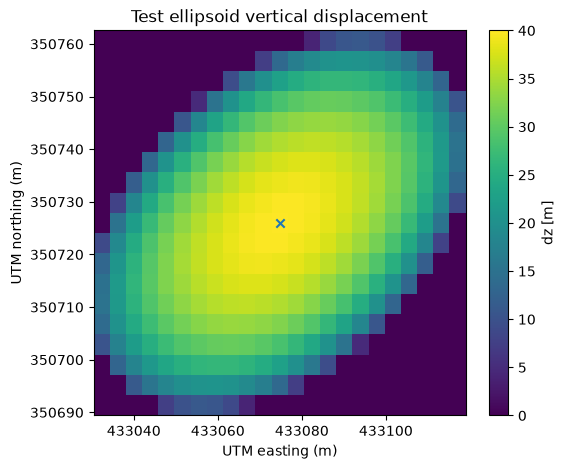

In [13]:
import xarray as xr
import matplotlib.pyplot as plt

dz_local_da = xr.DataArray(
    dz_local,
    dims=("y", "x"),
    coords={
        "y": y_local,
        "x": x_local,
    },
    name="dz",
    attrs={
        "units": "m",
        "description": "Vertical displacement from test ellipsoid",
    },
)

# Carry the projected CRS
dz_local_da = dz_local_da.rio.write_crs(dem_m_original.rio.crs)

print(dz_local_da)

print("\nCRS:", dz_local_da.rio.crs)
print("x range:", float(dz_local_da.x.min()), float(dz_local_da.x.max()))
print("y range:", float(dz_local_da.y.min()), float(dz_local_da.y.max()))

dz_local_da.plot(
    x="x",
    y="y",
    figsize=(6, 5),
)

plt.scatter(x0, y0, marker="x")
plt.title("Test ellipsoid vertical displacement")
plt.xlabel("UTM easting (m)")
plt.ylabel("UTM northing (m)")
plt.show()

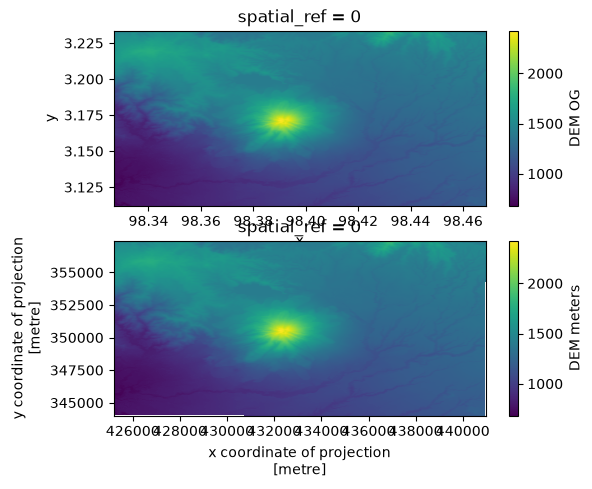

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2,1,figsize=(6, 5))

dem_geo_original.plot.pcolormesh(
    ax=axs[0],
    x="x",
    y="y",
    shading="auto",
    cbar_kwargs={"label": "DEM OG"},
)

dem_m_original.plot.pcolormesh(
    ax=axs[1],
    x="x",
    y="y",
    shading="auto",
    cbar_kwargs={"label": "DEM meters"},
)

# ax.scatter(
#     x0,
#     y0,
#     marker="x",
#     label="Shape centre",
# )

# ax.set_aspect("equal")
# ax.set_xlabel("UTM easting (m)")
# ax.set_ylabel("UTM northing (m)")
# ax.set_title("Test ellipsoid vertical displacement")
# ax.legend()

# plt.show()

In [15]:
plot_window = dict(
    x=slice(x0 - 1050, x0 - 50),
    y=slice(y0 + 100, y0 - 400),  # descending y
)

dem_plot = dem_m_original.sel(**plot_window)

print("Full DEM shape:", dem_m_original.shape)
print("Plot-only shape:", dem_plot.shape)

print("\nPlot bounds:")
print("x:", float(dem_plot.x.min()), "to", float(dem_plot.x.max()))
print("y:", float(dem_plot.y.min()), "to", float(dem_plot.y.max()))

Full DEM shape: (3489, 4100)
Plot-only shape: (129, 260)

Plot bounds:
x: 432027.59632776584 to 433024.65987123555
y: 350329.4610251532 to 350822.21829760156


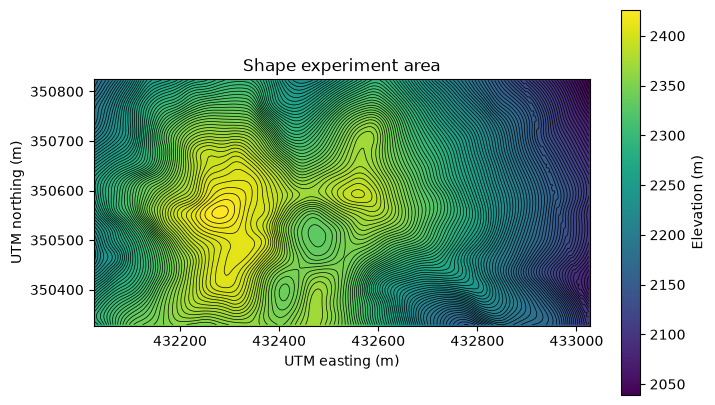

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

dem_plot.plot.pcolormesh(
    ax=ax,
    x="x",
    y="y",
    shading="auto",
    cbar_kwargs={"label": "Elevation (m)"},
)

dem_plot.plot.contour(
    ax=ax,
    x="x",
    y="y",
    levels=100,
    colors="k",
    linewidths=0.5,
)

ax.set_aspect("equal")
ax.set_xlabel("UTM easting (m)")
ax.set_ylabel("UTM northing (m)")
ax.set_title("Shape experiment area")

plt.show()

In [17]:
shape_x = 432450
shape_y = 350500

surface_z = float(
    dem_m_original.sel(
        x=shape_x,
        y=shape_y,
        method="nearest",
    )
)
depth_below_surface = 10.0

shape_z = surface_z - depth_below_surface


shape_spec = {
    "shape": "ellipsoid",
    "center": (shape_x, shape_y, shape_z),
    "semi_axes": (50.0, 30.0, 20.0),
    "rotation_deg": (30.0, 0.0, 0.0),
}

print("Shape location:")
print("x =", shape_x)
print("y =", shape_y)
print("local original DEM elevation =", surface_z)

Shape location:
x = 432450
y = 350500
local original DEM elevation = 2334.99658203125


In [18]:
import numpy as np
import xarray as xr

from toposhapes.shapes import rotation_matrix


def add_ellipsoid_to_dem(
    dem,
    *,
    center,
    semi_axes,
    rotation_deg=(0.0, 0.0, 0.0),
):
    """
    Add a 3-D rotated ellipsoid to an xarray/rioxarray DEM.

    Parameters
    ----------
    dem : xarray.DataArray
        Full projected DEM with dimensions ('y', 'x'), coordinates in metres.

    center : tuple
        Fixed ellipsoid centre (x, y, z) in metres.

    semi_axes : tuple
        Ellipsoid semi-axes (a, b, c) in metres.

    rotation_deg : tuple
        (yaw, pitch, roll) in degrees.

    Returns
    -------
    dem_modified : xarray.DataArray
        Full-size modified DEM.

    dz : xarray.DataArray
        Full-size vertical change. Zero means unchanged.
    """

    cx, cy, cz = map(float, center)
    axes = np.asarray(semi_axes, dtype=float)

    if axes.shape != (3,) or np.any(axes <= 0):
        raise ValueError("semi_axes must contain three positive values")

    R = rotation_matrix(*rotation_deg)
    Rt = R.T

    # Conservative horizontal bounding box of rotated ellipsoid
    half_x = np.sqrt(np.sum((R[0, :] * axes) ** 2))
    half_y = np.sqrt(np.sum((R[1, :] * axes) ** 2))

    xmin, xmax = cx - half_x, cx + half_x
    ymin, ymax = cy - half_y, cy + half_y

    x = dem.x.values
    y = dem.y.values

    cols = np.flatnonzero((x >= xmin) & (x <= xmax))
    rows = np.flatnonzero((y >= ymin) & (y <= ymax))

    # Full-size outputs
    dem_modified = dem.copy(deep=True)
    dz = xr.zeros_like(dem, dtype=np.float32)
    dz.name = "dz"
    dz.attrs["units"] = "m"

    if len(cols) == 0 or len(rows) == 0:
        return dem_modified, dz

    x_local = x[cols]
    y_local = y[rows]

    xx, yy = np.meshgrid(x_local, y_local)

    dx = xx - cx
    dy = yy - cy

    inv_axes_sq = 1.0 / axes**2

    # Local coordinates have form:
    # q(z_rel) = R.T @ [dx, dy, z_rel]
    #
    # Solve:
    # q.T @ D @ q = 1
    #
    # where z_rel is relative to ellipsoid centre cz.

    q0 = [
        Rt[i, 0] * dx + Rt[i, 1] * dy
        for i in range(3)
    ]

    vertical = Rt[:, 2]

    A = np.sum(vertical**2 * inv_axes_sq)

    B = 2.0 * sum(
        q0[i] * vertical[i] * inv_axes_sq[i]
        for i in range(3)
    )

    C = (
        sum(q0[i]**2 * inv_axes_sq[i] for i in range(3))
        - 1.0
    )

    discriminant = B**2 - 4.0 * A * C

    intersects = discriminant >= 0.0

    z_top = np.full(xx.shape, np.nan, dtype=float)

    sqrt_disc = np.sqrt(
        np.maximum(discriminant[intersects], 0.0)
    )

    # Upper ellipsoid surface, relative to cz
    z_rel_top = (
        -B[intersects] + sqrt_disc
    ) / (2.0 * A)

    z_top[intersects] = cz + z_rel_top

    row_slice = slice(rows[0], rows[-1] + 1)
    col_slice = slice(cols[0], cols[-1] + 1)

    terrain_local = dem.values[row_slice, col_slice]

    # Only raise terrain where ellipsoid surface is above it
    change_mask = (
        intersects
        & np.isfinite(terrain_local)
        & (z_top > terrain_local)
    )

    modified_local = terrain_local.copy()

    modified_local[change_mask] = z_top[change_mask]

    local_dz = np.zeros_like(terrain_local, dtype=np.float32)
    local_dz[change_mask] = (
        modified_local[change_mask]
        - terrain_local[change_mask]
    ).astype(np.float32)

    dem_modified.values[row_slice, col_slice] = modified_local

    dz.values[row_slice, col_slice] = local_dz

    return dem_modified, dz

In [19]:
# Choose horizontal position
shape_x = 432450
shape_y = 350500

# Choose z ONCE from some reference location
reference_surface_z = float(
    dem_m_original.sel(
        x=shape_x,
        y=shape_y,
        method="nearest",
    )
)

shape_z = reference_surface_z - 10.0

print("Reference terrain:", reference_surface_z)
print("Fixed ellipsoid centre z:", shape_z)

Reference terrain: 2334.99658203125
Fixed ellipsoid centre z: 2324.99658203125


In [20]:
dem_m_modified, dz = add_ellipsoid_to_dem(
    dem_m_original,
    center=(shape_x, shape_y, shape_z),
    semi_axes=(50.0, 50.0, 50.0),
    rotation_deg=(30.0, 0.0, 0.0),
)

print("Full original shape:", dem_m_original.shape)
print("Full modified shape:", dem_m_modified.shape)

print("Changed pixels:", int((dz > 0).sum()))
print("Maximum change:", float(dz.max()), "m")

Full original shape: (3489, 4100)
Full modified shape: (3489, 4100)
Changed pixels: 428
Maximum change: 41.672607421875 m


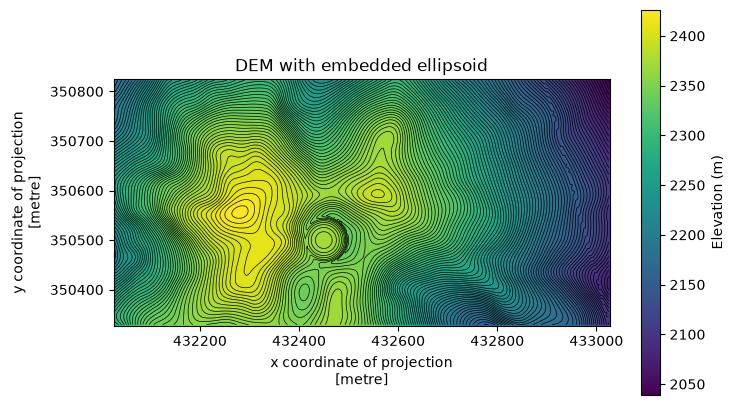

In [21]:
dem_modified_plot = dem_m_modified.sel(**plot_window)

fig, ax = plt.subplots(figsize=(8, 5))

dem_modified_plot.plot.pcolormesh(
    ax=ax,
    x="x",
    y="y",
    shading="auto",
    cbar_kwargs={"label": "Elevation (m)"},
)

dem_modified_plot.plot.contour(
    ax=ax,
    x="x",
    y="y",
    levels=100,
    colors="k",
    linewidths=0.5,
)

ax.set_aspect("equal")
ax.set_title("DEM with embedded ellipsoid")

plt.show()

In [23]:
from rasterio.enums import Resampling
import numpy as np

dem_geo_modified = dem_m_modified.rio.reproject_match(
    dem_geo_original,
    resampling=Resampling.nearest,
    nodata=np.nan,
)

print("--- dem_geo_modified ---")
print("Shape:", dem_geo_modified.shape)
print("CRS:", dem_geo_modified.rio.crs)
print("Resolution:", dem_geo_modified.rio.resolution())

print("\nOriginal shape:", dem_geo_original.shape)
print("Shape identical:", dem_geo_modified.shape == dem_geo_original.shape)

print("\nTransform identical:")
print(
    dem_geo_modified.rio.transform()
    == dem_geo_original.rio.transform()
)

print("\nX coordinates identical:")
print(np.array_equal(
    dem_geo_modified.x.values,
    dem_geo_original.x.values
))

print("Y coordinates identical:")
print(np.array_equal(
    dem_geo_modified.y.values,
    dem_geo_original.y.values
))

print("\nBounds:")
print("modified:", dem_geo_modified.rio.bounds())
print("original:", dem_geo_original.rio.bounds())

--- dem_geo_modified ---
Shape: (3497, 4089)
CRS: EPSG:4326
Resolution: (3.4722222999999716e-05, -3.472222299999998e-05)

Original shape: (3497, 4089)
Shape identical: True

Transform identical:
False

X coordinates identical:
True
Y coordinates identical:
True

Bounds:
modified: (98.32664923888849, 3.1122049472805, 98.4686284087355, 3.2336285611115)
original: (98.32664923888849, 3.1122049472805, 98.4686284087355, 3.2336285611115)


In [26]:
from pathlib import Path
import json
import numpy as np

# ------------------------------------------------------------------
# Output locations
# ------------------------------------------------------------------

out_dir = data_dir / "synthetic_test"
out_dir.mkdir(parents=True, exist_ok=True)

run_id = "test"

dem_out = out_dir / f"P.{run_id}.dem"
json_out = out_dir / f"{run_id}.json"


# ------------------------------------------------------------------
# 1. Verify that dem_geo_modified is on the exact original grid
# ------------------------------------------------------------------

assert dem_geo_modified.shape == dem_geo_original.shape

assert np.array_equal(
    dem_geo_modified.x.values,
    dem_geo_original.x.values,
)

assert np.array_equal(
    dem_geo_modified.y.values,
    dem_geo_original.y.values,
)

assert (
    dem_geo_modified.rio.transform()
    == dem_geo_original.rio.transform()
)

assert dem_geo_modified.rio.crs == dem_geo_original.rio.crs

print("Grid validation passed.")


# ------------------------------------------------------------------
# 2. Check that there are no NaNs before writing GAMMA binary
# ------------------------------------------------------------------

values = dem_geo_modified.values

n_nan = np.isnan(values).sum()

print("NaN pixels:", n_nan)

assert n_nan == 0, (
    "dem_geo_modified contains NaNs. "
    "Do not write the GAMMA DEM until these are resolved."
)


# ------------------------------------------------------------------
# 3. Write GAMMA REAL*4 big-endian binary
# ------------------------------------------------------------------

gamma_values = np.asarray(values, dtype=">f4")

gamma_values.tofile(dem_out)

print("\nWritten DEM:")
print(dem_out)

print("File size:", dem_out.stat().st_size, "bytes")

expected_bytes = (
    dem_geo_original.shape[0]
    * dem_geo_original.shape[1]
    * 4
)

print("Expected size:", expected_bytes, "bytes")

assert dem_out.stat().st_size == expected_bytes


# ------------------------------------------------------------------
# 4. Read it straight back and confirm the values survived exactly
# ------------------------------------------------------------------

check = np.fromfile(
    dem_out,
    dtype=">f4",
).reshape(dem_geo_original.shape)

print("\nRead-back shape:", check.shape)

print(
    "Read-back values exactly equal:",
    np.array_equal(check, gamma_values),
)

assert np.array_equal(check, gamma_values)


# ------------------------------------------------------------------
# 5. Save experiment metadata
# ------------------------------------------------------------------

metadata = {
    "id": run_id,

    "source_dem": str(dem_path),
    "source_dem_par": str(par_path),

    "output_dem": dem_out.name,

    "binary_format": {
        "data_format": "REAL*4",
        "numpy_dtype": ">f4",
        "byte_order": "big-endian",
        "shape": list(dem_geo_original.shape),
    },

    "grid": {
        "crs": str(dem_geo_original.rio.crs),
        "resolution": list(dem_geo_original.rio.resolution()),
        "bounds": list(dem_geo_original.rio.bounds()),
        "transform": list(dem_geo_original.rio.transform())[:6],
    },

    "shapes": [
        {
            "type": "ellipsoid",
            "center_xyz_m": [
                float(shape_x),
                float(shape_y),
                float(shape_z),
            ],
            "semi_axes_m": [50.0, 30.0, 20.0],
            "rotation_deg": [30.0, 0.0, 0.0],
            "operation": "add",
        }
    ],
}

with open(json_out, "w") as f:
    json.dump(metadata, f, indent=2)

print("\nWritten metadata:")
print(json_out)

AssertionError: 

In [27]:
t_orig = dem_geo_original.rio.transform()
t_mod  = dem_geo_modified.rio.transform()

print("Original transform:")
print(repr(t_orig))

print("\nModified transform:")
print(repr(t_mod))

print("\nCoefficient differences:")
for name in ["a", "b", "c", "d", "e", "f"]:
    v_orig = getattr(t_orig, name)
    v_mod = getattr(t_mod, name)
    print(
        f"{name}: "
        f"orig={v_orig:.17g}, "
        f"mod={v_mod:.17g}, "
        f"diff={v_mod - v_orig:.3e}"
    )

print("\nExact equality:", t_mod == t_orig)

print(
    "Numerically equal:",
    np.allclose(
        tuple(t_mod)[:6],
        tuple(t_orig)[:6],
        rtol=0.0,
        atol=1e-12,
    )
)

print(
    "\nX coordinates exactly equal:",
    np.array_equal(
        dem_geo_modified.x.values,
        dem_geo_original.x.values,
    )
)

print(
    "Y coordinates exactly equal:",
    np.array_equal(
        dem_geo_modified.y.values,
        dem_geo_original.y.values,
    )
)

Original transform:
Affine(3.4722223e-05, 0.0, 98.32664923888849,
       0.0, -3.4722223e-05, 3.2336285611115)

Modified transform:
Affine(3.4722222999999716e-05, 0.0, 98.32664923888849,
       0.0, -3.472222299999998e-05, 3.2336285611115)

Coefficient differences:
a: orig=3.4722223000000001e-05, mod=3.4722222999999716e-05, diff=-2.846e-19
b: orig=0, mod=0, diff=0.000e+00
c: orig=98.326649238888493, mod=98.326649238888493, diff=0.000e+00
d: orig=0, mod=0, diff=0.000e+00
e: orig=-3.4722223000000001e-05, mod=-3.472222299999998e-05, diff=2.033e-20
f: orig=3.2336285611114999, mod=3.2336285611114999, diff=0.000e+00

Exact equality: False
Numerically equal: True

X coordinates exactly equal: True
Y coordinates exactly equal: True


In [28]:
dem_geo_modified = dem_geo_modified.assign_coords(
    x=dem_geo_original.x,
    y=dem_geo_original.y,
)

dem_geo_modified = dem_geo_modified.rio.write_crs(
    dem_geo_original.rio.crs,
    inplace=False,
)

dem_geo_modified = dem_geo_modified.rio.write_transform(
    dem_geo_original.rio.transform(),
    inplace=False,
)

In [29]:
print("Shape exact:",
      dem_geo_modified.shape == dem_geo_original.shape)

print("X exact:",
      np.array_equal(
          dem_geo_modified.x.values,
          dem_geo_original.x.values
      ))

print("Y exact:",
      np.array_equal(
          dem_geo_modified.y.values,
          dem_geo_original.y.values
      ))

print("Transform exact:",
      dem_geo_modified.rio.transform()
      == dem_geo_original.rio.transform())

print("CRS exact:",
      dem_geo_modified.rio.crs
      == dem_geo_original.rio.crs)

Shape exact: True
X exact: True
Y exact: True
Transform exact: True
CRS exact: True


In [31]:
import numpy as np
import xarray as xr

nan_mask = np.isnan(dem_geo_modified.values)

print("NaN pixels before fill:", nan_mask.sum())

dem_geo_modified = xr.where(
    np.isfinite(dem_geo_modified),
    dem_geo_modified,
    dem_geo_original,
)

print("NaN pixels after fill:",
      np.isnan(dem_geo_modified.values).sum())

# Verify that only NaN locations were replaced
replaced_values_match_original = np.array_equal(
    dem_geo_modified.values[nan_mask],
    dem_geo_original.values[nan_mask],
)

print("Filled pixels exactly restored from original:",
      replaced_values_match_original)

NaN pixels before fill: 6
NaN pixels after fill: 0
Filled pixels exactly restored from original: True


In [32]:
dem_geo_modified = dem_geo_modified.assign_coords(
    x=dem_geo_original.x,
    y=dem_geo_original.y,
)

dem_geo_modified = dem_geo_modified.rio.write_crs(
    dem_geo_original.rio.crs,
    inplace=False,
)

dem_geo_modified = dem_geo_modified.rio.write_transform(
    dem_geo_original.rio.transform(),
    inplace=False,
)

In [33]:
print("NaN pixels:",
      np.isnan(dem_geo_modified.values).sum())

print("Shape exact:",
      dem_geo_modified.shape == dem_geo_original.shape)

print("Transform exact:",
      dem_geo_modified.rio.transform()
      == dem_geo_original.rio.transform())

NaN pixels: 0
Shape exact: True
Transform exact: True


In [34]:
from pathlib import Path
import json
import numpy as np

out_dir = data_dir / "synthetic_test"
out_dir.mkdir(parents=True, exist_ok=True)

run_id = "test"

dem_out = out_dir / f"P.{run_id}.dem"
json_out = out_dir / f"{run_id}.json"

# Final grid checks
assert dem_geo_modified.shape == dem_geo_original.shape
assert np.array_equal(dem_geo_modified.x.values, dem_geo_original.x.values)
assert np.array_equal(dem_geo_modified.y.values, dem_geo_original.y.values)
assert dem_geo_modified.rio.transform() == dem_geo_original.rio.transform()
assert dem_geo_modified.rio.crs == dem_geo_original.rio.crs
assert np.isnan(dem_geo_modified.values).sum() == 0

# Write GAMMA REAL*4 big-endian
values_be = np.asarray(dem_geo_modified.values, dtype=">f4")
values_be.tofile(dem_out)

expected_bytes = dem_geo_original.size * 4

print("Written:", dem_out)
print("File size:", dem_out.stat().st_size)
print("Expected:", expected_bytes)

# Read straight back
check = np.fromfile(
    dem_out,
    dtype=">f4",
).reshape(dem_geo_original.shape)

print("\nRead-back shape:", check.shape)
print("Read-back exact:", np.array_equal(check, values_be))
print("Min:", float(check.min()))
print("Max:", float(check.max()))

assert dem_out.stat().st_size == expected_bytes
assert np.array_equal(check, values_be)

Written: /Users/elioteaton/Documents/git_repos/toposhapes_package/data/synthetic_test/P.test.dem
File size: 57196932
Expected: 57196932

Read-back shape: (3497, 4089)
Read-back exact: True
Min: 681.786865234375
Max: 2425.986572265625


In [36]:
import json
import numpy as np

# ------------------------------------------------------------
# Calculate validation statistics directly from the DEMs
# ------------------------------------------------------------

original_values = dem_geo_original.values.astype(np.float32)
modified_values = dem_geo_modified.values.astype(np.float32)

difference = modified_values - original_values
changed = difference != 0

n_changed = int(np.count_nonzero(changed))
changed_fraction = float(np.mean(changed))

print("Changed pixels:", n_changed)
print("Changed percent:", 100 * changed_fraction)

# ------------------------------------------------------------
# Build provenance metadata
# ------------------------------------------------------------

metadata = {
    "id": run_id,

    "source_dem": str(dem_path),
    "source_dem_par": str(par_path),

    "output_dem": dem_out.name,

    "binary_format": {
        "data_format": "REAL*4",
        "numpy_dtype": ">f4",
        "byte_order": "big-endian",
        "shape": list(dem_geo_original.shape),
    },

    "grid": {
        "crs": str(dem_geo_original.rio.crs),

        "resolution": [
            float(v)
            for v in dem_geo_original.rio.resolution()
        ],

        "bounds": [
            float(v)
            for v in dem_geo_original.rio.bounds()
        ],

        "transform": [
            float(v)
            for v in tuple(dem_geo_original.rio.transform())[:6]
        ],
    },

    "shapes": [
        {
            "type": "ellipsoid",

            "center_xyz_m": [
                float(shape_x),
                float(shape_y),
                float(shape_z),
            ],

            "semi_axes_m": [
                50.0,
                30.0,
                20.0,
            ],

            "rotation_deg": [
                30.0,
                0.0,
                0.0,
            ],

            "operation": "add",
        }
    ],

    "validation": {
        "changed_pixels": n_changed,
        "changed_fraction": changed_fraction,
        "changed_percent": 100 * changed_fraction,

        "min_change_m": (
            float(difference[changed].min())
            if n_changed else 0.0
        ),

        "max_change_m": (
            float(difference[changed].max())
            if n_changed else 0.0
        ),

        "mean_change_m": (
            float(difference[changed].mean())
            if n_changed else 0.0
        ),

        "unchanged_pixels_exact": bool(
            np.array_equal(
                modified_values[~changed],
                original_values[~changed],
            )
        ),
    },
}

# ------------------------------------------------------------
# Write JSON
# ------------------------------------------------------------

with open(json_out, "w") as f:
    json.dump(metadata, f, indent=2)

print("\nWritten:", json_out)

print("\nValidation:")
print(json.dumps(metadata["validation"], indent=2))

Changed pixels: 42793
Changed percent: 0.2992677998882877

Written: /Users/elioteaton/Documents/git_repos/toposhapes_package/data/synthetic_test/test.json

Validation:
{
  "changed_pixels": 42793,
  "changed_fraction": 0.002992677998882877,
  "changed_percent": 0.2992677998882877,
  "min_change_m": -4.698974609375,
  "max_change_m": 41.672607421875,
  "mean_change_m": 0.2372950315475464,
  "unchanged_pixels_exact": true
}


In [38]:
metadata = {
    "id": run_id,

    "source_dem": str(dem_path),
    "source_dem_par": str(par_path),

    "output_dem": dem_out.name,

    "binary_format": {
        "data_format": "REAL*4",
        "numpy_dtype": ">f4",
        "byte_order": "big-endian",
        "shape": list(dem_geo_original.shape),
    },

    "grid": {
        "crs": str(dem_geo_original.rio.crs),
        "resolution": [
            float(dem_geo_original.rio.resolution()[0]),
            float(dem_geo_original.rio.resolution()[1]),
        ],
        "bounds": [
            float(v) for v in dem_geo_original.rio.bounds()
        ],
        "transform": [
            float(v)
            for v in tuple(dem_geo_original.rio.transform())[:6]
        ],
    },

    "shapes": [
        {
            "type": "ellipsoid",

            "center_xyz_m": [
                float(shape_x),
                float(shape_y),
                float(shape_z),
            ],

            "semi_axes_m": [
                50.0,
                30.0,
                20.0,
            ],

            "rotation_deg": [
                30.0,
                0.0,
                0.0,
            ],

            "operation": "add",
        }
    ],

    "validation": {
        "changed_pixels": int(np.count_nonzero(changed)),
        "changed_fraction": float(np.mean(changed)),
        "changed_percent": float(100 * np.mean(changed)),
        "min_change_m": (
            float(difference[changed].min())
            if np.any(changed) else 0.0
        ),
        "max_change_m": (
            float(difference[changed].max())
            if np.any(changed) else 0.0
        ),
        "mean_change_m": (
            float(difference[changed].mean())
            if np.any(changed) else 0.0
        ),
    },
}

with open(json_out, "w") as f:
    json.dump(metadata, f, indent=2)

print("Written:", json_out)

print("\nJSON contents:")
print(json.dumps(metadata, indent=2))

Written: /Users/elioteaton/Documents/git_repos/toposhapes_package/data/synthetic_test/test.json

JSON contents:
{
  "id": "test",
  "source_dem": "/Users/elioteaton/Documents/git_repos/toposhapes_package/data/P.dem",
  "source_dem_par": "/Users/elioteaton/Documents/git_repos/toposhapes_package/data/P.dem_par",
  "output_dem": "P.test.dem",
  "binary_format": {
    "data_format": "REAL*4",
    "numpy_dtype": ">f4",
    "byte_order": "big-endian",
    "shape": [
      3497,
      4089
    ]
  },
  "grid": {
    "crs": "EPSG:4326",
    "resolution": [
      3.4722223e-05,
      -3.4722223e-05
    ],
    "bounds": [
      98.32664923888849,
      3.1122049472805,
      98.4686284087355,
      3.2336285611115
    ],
    "transform": [
      3.4722223e-05,
      0.0,
      98.32664923888849,
      0.0,
      -3.4722223e-05,
      3.2336285611115
    ]
  },
  "shapes": [
    {
      "type": "ellipsoid",
      "center_xyz_m": [
        432450.0,
        350500.0,
        2324.99658203125
     

In [40]:
import numpy as np
import xarray as xr
from rasterio.enums import Resampling

# Fresh projected modification mask:
# 1 = intentionally modified
# 0 = unchanged
modified_mask_m = xr.DataArray(
    (dz.values > 0).astype(np.uint8),
    dims=dem_m_original.dims,
    coords={
        "y": dem_m_original.y,
        "x": dem_m_original.x,
    },
    name="modified_mask",
)

modified_mask_m = modified_mask_m.rio.write_crs(
    dem_m_original.rio.crs,
    inplace=False,
)

modified_mask_m = modified_mask_m.rio.write_transform(
    dem_m_original.rio.transform(),
    inplace=False,
)

modified_mask_m = modified_mask_m.rio.write_nodata(
    0,
    inplace=False,
)

print("Mask dtype:", modified_mask_m.dtype)
print("Mask nodata:", modified_mask_m.rio.nodata)
print("Projected changed pixels:", int(modified_mask_m.sum()))

# Reproject mask onto exact original geographic grid
modified_mask_geo = modified_mask_m.rio.reproject_match(
    dem_geo_original,
    resampling=Resampling.nearest,
    nodata=0,
)

modified_mask_geo = modified_mask_geo.astype(bool)

print("Geographic mask pixels:", int(modified_mask_geo.sum()))

Mask dtype: uint8
Mask nodata: 0
Projected changed pixels: 428
Geographic mask pixels: 428


In [41]:
# For an ADD operation, only retain positive modifications
candidate = xr.where(
    dem_geo_modified > dem_geo_original,
    dem_geo_modified,
    dem_geo_original,
)

dem_geo_modified_clean = xr.where(
    modified_mask_geo,
    candidate,
    dem_geo_original,
)

# Restore authoritative grid metadata
dem_geo_modified_clean = dem_geo_modified_clean.assign_coords(
    x=dem_geo_original.x,
    y=dem_geo_original.y,
)

dem_geo_modified_clean = dem_geo_modified_clean.rio.write_crs(
    dem_geo_original.rio.crs,
    inplace=False,
)

dem_geo_modified_clean = dem_geo_modified_clean.rio.write_transform(
    dem_geo_original.rio.transform(),
    inplace=False,
)

In [42]:
difference_clean = (
    dem_geo_modified_clean.astype(np.float32)
    - dem_geo_original.astype(np.float32)
)

changed_clean = difference_clean.values != 0
negative_clean = difference_clean.values < 0

print("Changed pixels:", np.count_nonzero(changed_clean))
print("Changed percent:", 100 * np.mean(changed_clean))

print("Negative changes:", np.count_nonzero(negative_clean))

print(
    "Outside modification footprint exactly original:",
    np.array_equal(
        dem_geo_modified_clean.values[~modified_mask_geo.values],
        dem_geo_original.values[~modified_mask_geo.values],
    )
)

if np.any(changed_clean):
    print("Min change:", float(difference_clean.values[changed_clean].min()))
    print("Max change:", float(difference_clean.values[changed_clean].max()))
    print("Mean change:", float(difference_clean.values[changed_clean].mean()))

Changed pixels: 428
Changed percent: 0.0029931675356293587
Negative changes: 0
Outside modification footprint exactly original: True
Min change: 0.021484375
Max change: 41.672607421875
Mean change: 23.312225341796875
